In [2]:
#=======task 1 >> data cleaning=====
import pandas as pd

# ==========================================
# 1. Load the dataset
# ==========================================
# Make sure you have uploaded 'churn-bigml-20.csv' to the left sidebar first!
file_name = 'churn-bigml-20.csv'
df = pd.read_csv(file_name)

print("✅ Step 1: Data Loaded Successfully")
print(f"Original Data Shape: {df.shape}")

# ==========================================
# 2. Handle Missing Values
# ==========================================
# Filling numeric columns with their mean
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Filling categorical (text) columns with the most frequent value (mode)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Step 2: Missing Values Handled (Imputation)")

# ==========================================
# 3. Remove Duplicate Rows
# ==========================================
initial_count = len(df)
df = df.drop_duplicates()
final_count = len(df)

print(f"✅ Step 3: Duplicates Removed. Rows deleted: {initial_count - final_count}")

# ==========================================
# 4. Standardize Data Formats
# ==========================================
# Standardize Column Names: lowercase and replace spaces with underscores
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# Standardize Text: trim whitespace and use Title Case for states
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip().str.title()

# Standardize Boolean: Convert 'churn' to 0/1 (int) for easier AI modeling
df['churn'] = df['churn'].astype(int)

print("✅ Step 4: Data Formats Standardized")

# ==========================================
# 5. Save the Cleaned Dataset
# ==========================================
output_file = 'cleaned_churn_data.csv'
df.to_csv(output_file, index=False)

print(f"\n🚀 ALL STEPS COMPLETE!")
print(f"Cleaned file saved as: {output_file}")
print("-" * 30)
print(df.head()) # Preview the first 5 rows

✅ Step 1: Data Loaded Successfully
Original Data Shape: (667, 20)
✅ Step 2: Missing Values Handled (Imputation)
✅ Step 3: Duplicates Removed. Rows deleted: 0
✅ Step 4: Data Formats Standardized

🚀 ALL STEPS COMPLETE!
Cleaned file saved as: cleaned_churn_data.csv
------------------------------
  state  account_length  area_code international_plan voice_mail_plan  \
0    La             117        408                 No              No   
1    In              65        415                 No              No   
2    Ny             161        415                 No              No   
3    Sc             111        415                 No              No   
4    Hi              49        510                 No              No   

   number_vmail_messages  total_day_minutes  total_day_calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3          

--- Summary Statistics ---
       account_length   area_code  number_vmail_messages  total_day_minutes  \
count      667.000000  667.000000             667.000000         667.000000   
mean       102.841079  436.157421               8.407796         180.948126   
std         40.819480   41.783305              13.994480          55.508628   
min          1.000000  408.000000               0.000000          25.900000   
25%         76.000000  408.000000               0.000000         146.250000   
50%        102.000000  415.000000               0.000000         178.300000   
75%        128.000000  415.000000              20.000000         220.700000   
max        232.000000  510.000000              51.000000         334.300000   

       total_day_calls  total_day_charge  total_eve_minutes  total_eve_calls  \
count       667.000000        667.000000         667.000000       667.000000   
mean        100.937031         30.761769         203.355322       100.476762   
std          20.39679

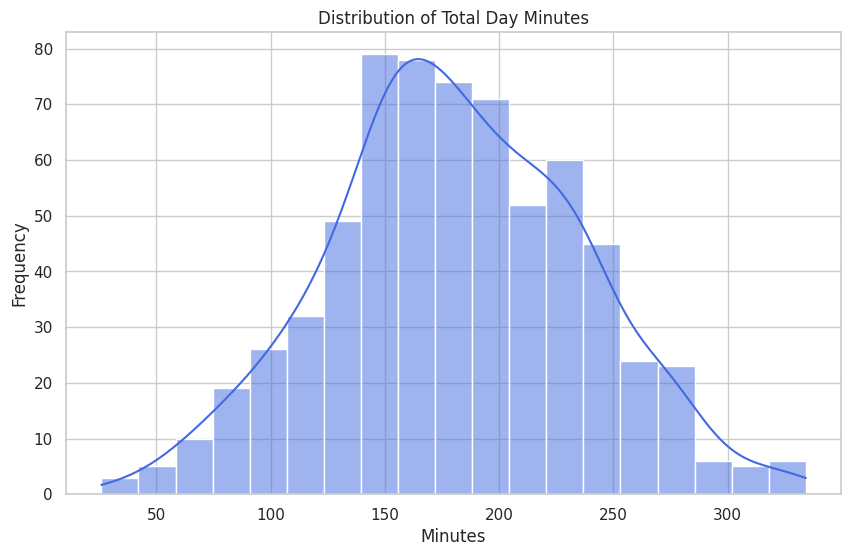

/tmp/ipykernel_731/3531441099.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='customer_service_calls', data=df, palette='Set1')


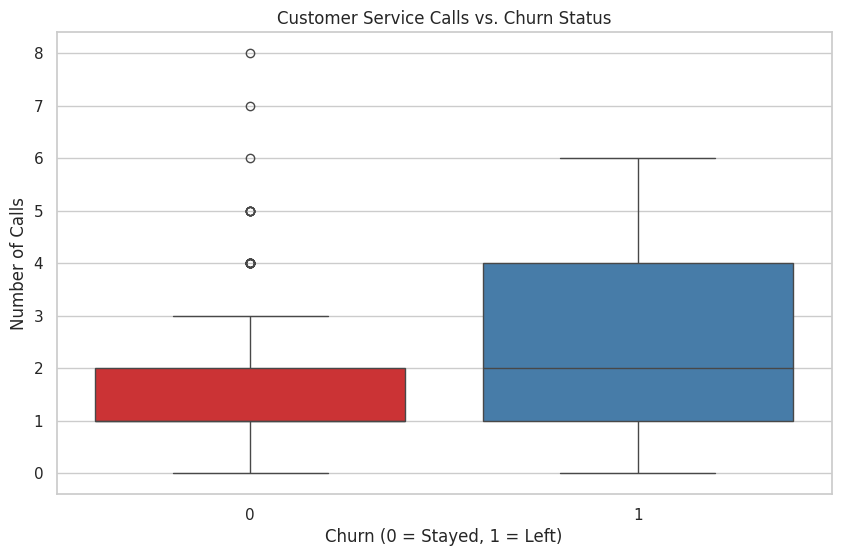

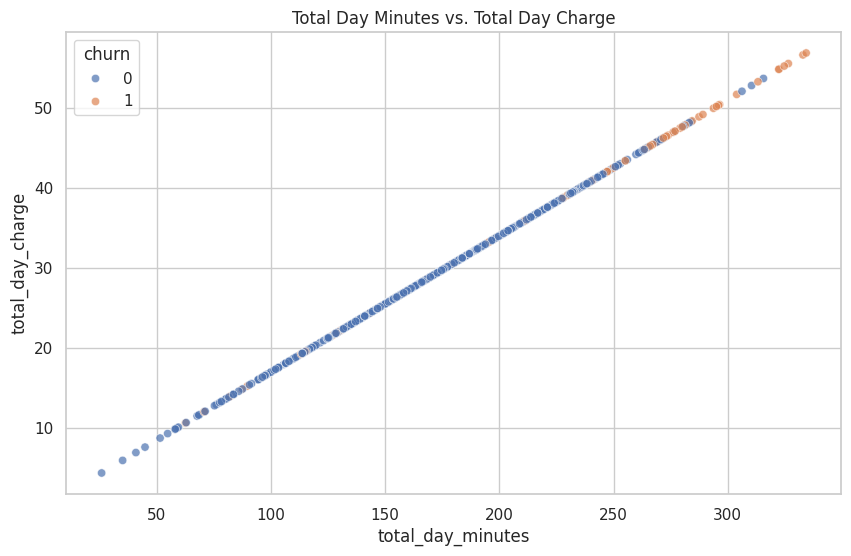

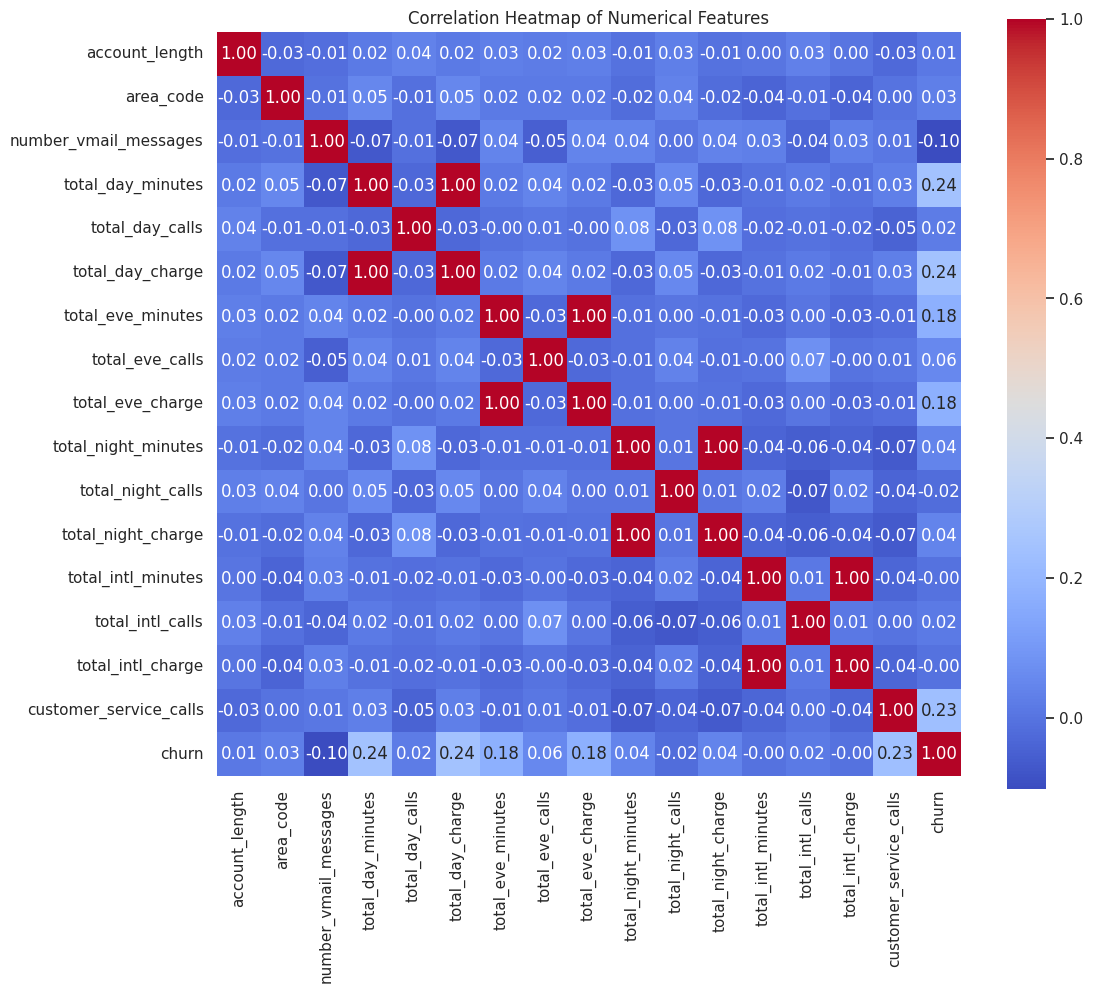

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the cleaned dataset from Task 1
# Ensure 'cleaned_churn_data.csv' is in your Colab file list
df = pd.read_csv('cleaned_churn_data.csv')

# ==========================================
# 2. Descriptive Statistics
# ==========================================
# Generates mean, std, min, max, and quartiles for all numeric columns
summary_stats = df.describe()

# Mode (most frequent value) is calculated separately
mode_values = df.mode().iloc[0]

print("--- Summary Statistics ---")
print(summary_stats)
print("\n--- Mode Values ---")
print(mode_values)

# ==========================================
# 3. Data Visualization
# ==========================================
# Set the visual style for all plots
sns.set_theme(style="whitegrid")

# (A) Histogram: Distribution of 'Total Day Minutes'
# Goal: Understand the spread and center of customer usage
plt.figure(figsize=(10, 6))
sns.histplot(df['total_day_minutes'], kde=True, color='royalblue')
plt.title('Distribution of Total Day Minutes')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.show()

# (B) Boxplot: Customer Service Calls vs. Churn
# Goal: See if high support demand relates to customers leaving
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='customer_service_calls', data=df, palette='Set1')
plt.title('Customer Service Calls vs. Churn Status')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Calls')
plt.show()

# (C) Scatter Plot: Total Day Minutes vs. Total Day Charge
# Goal: Confirm the relationship between usage and billing
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_day_minutes', y='total_day_charge', hue='churn', data=df, alpha=0.7)
plt.title('Total Day Minutes vs. Total Day Charge')
plt.show()

# ==========================================
# 4. Correlation Analysis
# ==========================================
# Goal: Find how variables interact with each other
plt.figure(figsize=(12, 10))
# Calculate correlation matrix for numeric features only
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

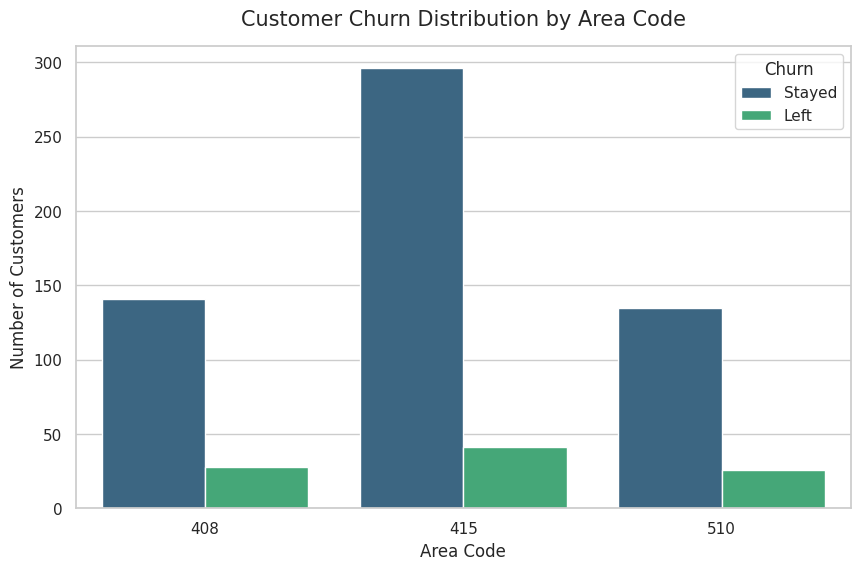

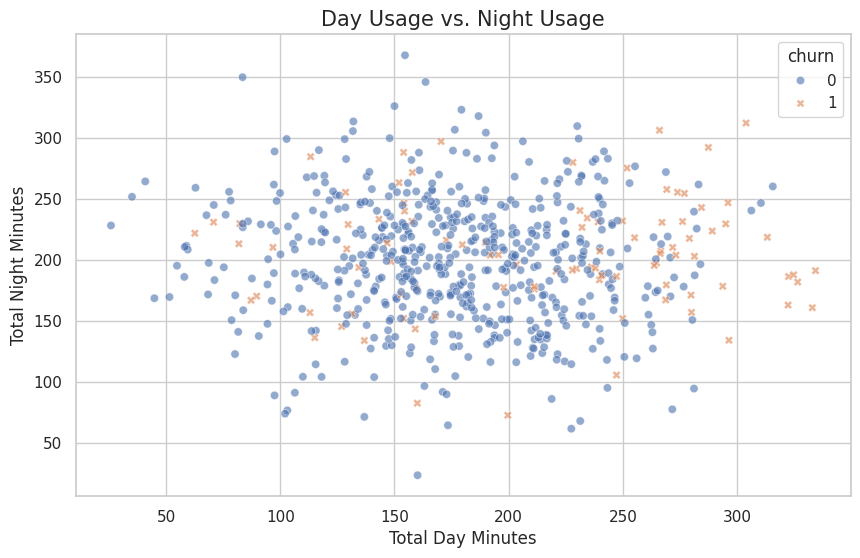

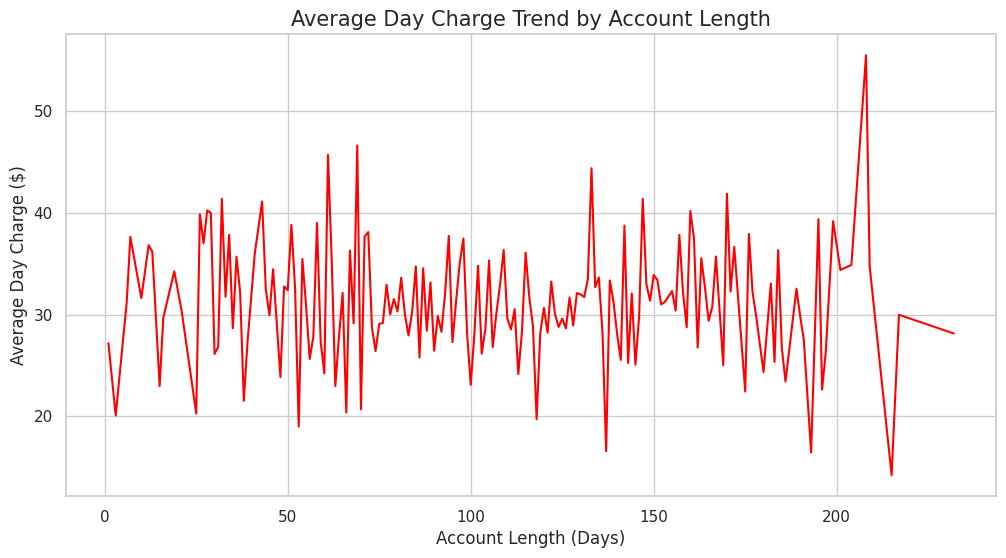

🚀 Task 3 Complete: All plots customized and exported as images!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the cleaned data
df = pd.read_csv('cleaned_churn_data.csv')

# Set global aesthetic style
sns.set_theme(style="whitegrid")

# ==========================================
# (A) Bar Plot: Churn Count by Area Code
# ==========================================
plt.figure(figsize=(10, 6))
# Using countplot to show distribution across categories
ax = sns.countplot(x='area_code', hue='churn', data=df, palette='viridis')

# Customizing Labels and Title
plt.title('Customer Churn Distribution by Area Code', fontsize=15, pad=15)
plt.xlabel('Area Code', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['Stayed', 'Left'])

# Exporting the plot
plt.savefig('bar_plot_area_code.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# (B) Scatter Plot: Day Minutes vs. Night Minutes
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_day_minutes', y='total_night_minutes',
                hue='churn', style='churn', data=df, alpha=0.6)

# Customizing Plot
plt.title('Day Usage vs. Night Usage', fontsize=15)
plt.xlabel('Total Day Minutes', fontsize=12)
plt.ylabel('Total Night Minutes', fontsize=12)

# Exporting the plot
plt.savefig('scatter_usage_comparison.png', dpi=300)
plt.show()

# ==========================================
# (C) Line Chart: Avg Day Charge by Account Length
# ==========================================
# Note: Line charts usually show trends. We will group account lengths to show a trend.
plt.figure(figsize=(12, 6))

# Grouping by account length and calculating average charge
trend_data = df.groupby('account_length')['total_day_charge'].mean().reset_index()

sns.lineplot(x='account_length', y='total_day_charge', data=trend_data, color='red')

# Customizing Plot
plt.title('Average Day Charge Trend by Account Length', fontsize=15)
plt.xlabel('Account Length (Days)', fontsize=12)
plt.ylabel('Average Day Charge ($)', fontsize=12)

# Exporting the plot
plt.savefig('line_chart_charge_trend.png', dpi=300)
plt.show()

print("🚀 Task 3 Complete: All plots customized and exported as images!")